In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/data.csv')
df

,km,price
0,240000,3650
1,139800,3800
2,150500,4400
3,185530,4450
4,176000,5250
5,114800,5350
6,166800,5800
7,89000,5990
8,144500,5999
9,84000,6200


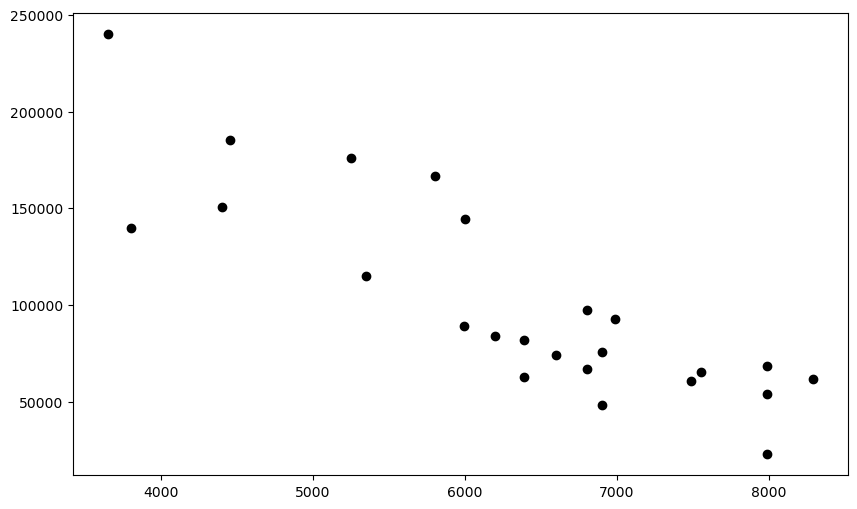

In [61]:
X = df['price']
Y = df['km']
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='black');

In [96]:
m = 0
c = 0

learning_r = 0.1
epochs = 1000

n = float(len(X))

# X_S = (X - np.mean(X)) / np.std(X)  # Standardization
# Y_S = (Y - np.mean(Y)) / np.std(Y)

X_S = (X - np.min(X)) / (np.max(X) - np.min(X))  # Min-Max Scaling
Y_S = (Y - np.min(Y)) / (np.max(Y) - np.min(Y))

for i in range(epochs):
    Y_preds = m * X_S + c

    D_m = (-2/n) * np.sum(X_S * (Y_S - Y_preds))
    D_c = (-2/n) * np.sum((Y_S - Y_preds))

    if i % 100 == 0:
        print(f"Iteration {i}: m={m:.5f}, c={c:.5f}, D_m={D_m:.5f}, D_c={D_c:.5f}")
    
    m = m - learning_r * D_m
    c = c - learning_r * D_c

print (f"end m = {m}, end c = {c}")

Iteration 0: m=0.00000, c=0.00000, D_m=-0.30297, D_c=-0.72010
Iteration 100: m=-0.45229, c=0.61171, D_m=0.03183, D_c=-0.01952
Iteration 200: m=-0.64243, c=0.72828, D_m=0.01007, D_c=-0.00617
Iteration 300: m=-0.70256, c=0.76514, D_m=0.00318, D_c=-0.00195
Iteration 400: m=-0.72157, c=0.77680, D_m=0.00101, D_c=-0.00062
Iteration 500: m=-0.72758, c=0.78048, D_m=0.00032, D_c=-0.00020
Iteration 600: m=-0.72948, c=0.78165, D_m=0.00010, D_c=-0.00006
Iteration 700: m=-0.73009, c=0.78202, D_m=0.00003, D_c=-0.00002
Iteration 800: m=-0.73028, c=0.78213, D_m=0.00001, D_c=-0.00001
Iteration 900: m=-0.73034, c=0.78217, D_m=0.00000, D_c=-0.00000
end m = -0.7303543269390277, end c = 0.7821810118207295


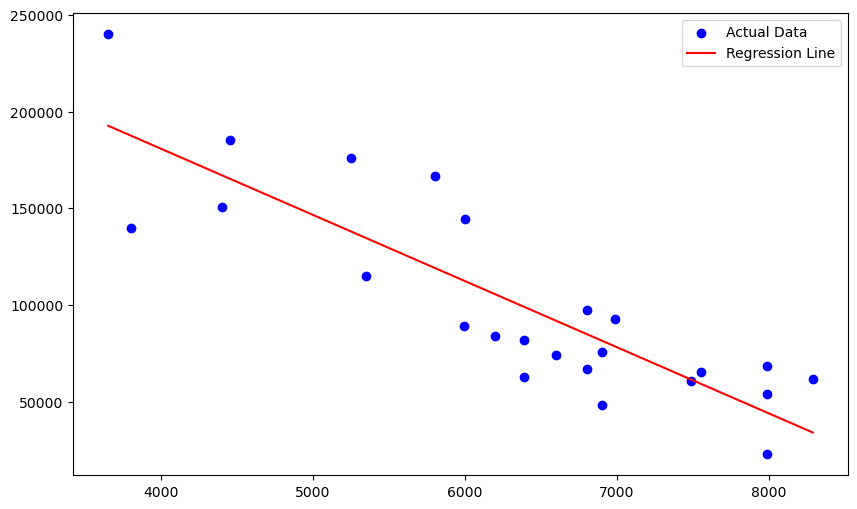

In [99]:
Y_preds = m * X_S + c

Y_preds_original = Y_preds * (Y.max() - Y.min()) + Y.min()


plt.figure(figsize=(10, 6))
plt.scatter(X, Y, label="Actual Data", color='blue')
plt.plot(X, Y_preds_original, label="Regression Line", color='red')
plt.legend()
plt.show()